In [1]:
!pip install plotly kaleido


   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   -------------------------------- ------- 4/5 [kaleido]
   ---------------------------------------- 5/5 [kaleido]



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\NAREDLA POOJITHA\Downloads\2019-Oct.csv\2019-Oct.csv', nrows=500000)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nEvent type counts:")
print(df['event_type'].value_counts())
print("\nFirst 3 rows:")
df.head(3)

Shape: (500000, 9)

Columns: ['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']

Event type counts:
event_type
view        481833
purchase      9758
cart          8409
Name: count, dtype: int64

First 3 rows:


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8


In [4]:
# Convert event_time to datetime
df['event_time'] = pd.to_datetime(df['event_time'])

# Extract time features
df['date'] = df['event_time'].dt.date
df['hour'] = df['event_time'].dt.hour
df['day_of_week'] = df['event_time'].dt.day_name()

# Drop rows with missing user_id or event_type
df = df.dropna(subset=['user_id', 'event_type'])

# Fill missing brand and category
df['brand'] = df['brand'].fillna('Unknown')
df['category_code'] = df['category_code'].fillna('Unknown')

# Extract main category
df['main_category'] = df['category_code'].apply(
    lambda x: x.split('.')[0] if x != 'Unknown' else 'Unknown'
)

print("Cleaned shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nMain categories found:")
print(df['main_category'].value_counts().head(10))

Cleaned shape: (500000, 13)

Missing values:
event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     0
date             0
hour             0
day_of_week      0
main_category    0
dtype: int64

Main categories found:
main_category
electronics     191696
Unknown         158439
appliances       59624
computers        28663
apparel          14431
furniture        13352
auto             12571
construction      9548
kids              6380
accessories       2703
Name: count, dtype: int64


In [11]:
# Unique users at each stage
users_viewed = df[df['event_type'] == 'view']['user_id'].nunique()
users_carted = df[df['event_type'] == 'cart']['user_id'].nunique()
users_purchased = df[df['event_type'] == 'purchase']['user_id'].nunique()

# Total unique users who did anything
total_users = df['user_id'].nunique()

# Correct funnel — measure each stage against total users
view_rate = (users_viewed / total_users) * 100
cart_rate = (users_carted / total_users) * 100
purchase_rate = (users_purchased / total_users) * 100

# View to purchase (skip cart since many buy directly)
view_to_purchase = (users_purchased / users_viewed) * 100

print("=" * 45)
print("   MARKETING FUNNEL METRICS")
print("=" * 45)
print(f"Total Unique Users:    {total_users:,}")
print(f"Users who Viewed:      {users_viewed:,}  ({view_rate:.1f}%)")
print(f"Users who Carted:      {users_carted:,}   ({cart_rate:.1f}%)")
print(f"Users who Purchased:   {users_purchased:,}   ({purchase_rate:.1f}%)")
print("-" * 45)
print(f"View → Purchase Rate:  {view_to_purchase:.2f}%")
print(f"Browse-Only Users:     {users_viewed - users_purchased:,} ({100-view_to_purchase:.1f}% didn't buy)")
print("-" * 45)

# Key insight: direct buyers vs cart users
cart_users = set(df[df['event_type']=='cart']['user_id'])
purchase_users = set(df[df['event_type']=='purchase']['user_id'])
direct_buyers = purchase_users - cart_users
cart_then_buy = purchase_users & cart_users

print(f"\nPurchase Behavior Breakdown:")
print(f"Bought via Cart:    {len(cart_then_buy):,} users ({len(cart_then_buy)/len(purchase_users)*100:.1f}%)")
print(f"Direct Purchase:    {len(direct_buyers):,} users ({len(direct_buyers)/len(purchase_users)*100:.1f}%)")

   MARKETING FUNNEL METRICS
Total Unique Users:    89,124
Users who Viewed:      89,108  (100.0%)
Users who Carted:      4,441   (5.0%)
Users who Purchased:   7,362   (8.3%)
---------------------------------------------
View → Purchase Rate:  8.26%
Browse-Only Users:     81,746 (91.7% didn't buy)
---------------------------------------------

Purchase Behavior Breakdown:
Bought via Cart:    2,755 users (37.4%)
Direct Purchase:    4,607 users (62.6%)


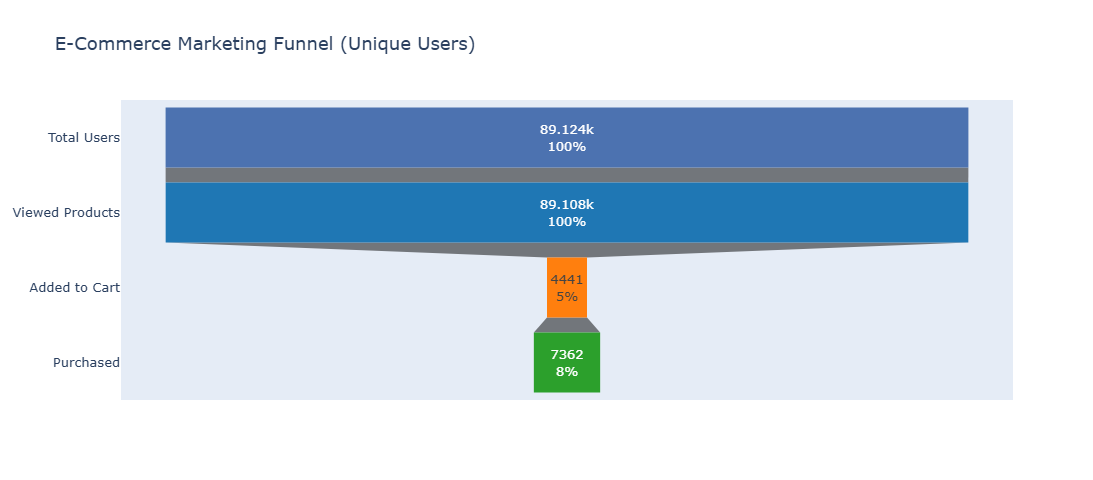

Funnel chart saved!


In [12]:
fig = go.Figure(go.Funnel(
    y = ['Total Users', 'Viewed Products', 'Added to Cart', 'Purchased'],
    x = [total_users, users_viewed, users_carted, users_purchased],
    textinfo = "value+percent initial",
    marker_color = ['#4C72B0', '#1f77b4', '#ff7f0e', '#2ca02c'],
    textfont = dict(size=13)
))
fig.update_layout(
    title='E-Commerce Marketing Funnel (Unique Users)',
    font=dict(size=13),
    width=700, height=480
)
fig.show()
fig.write_image('funnel_chart.png')
print("Funnel chart saved!")

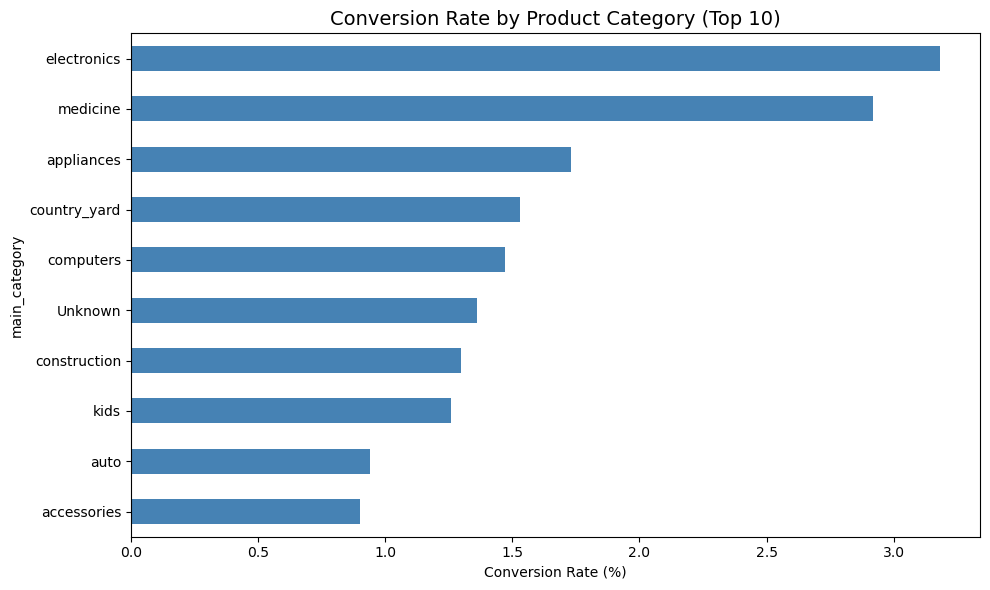

event_type       view  cart  purchase  conversion_rate
main_category                                         
electronics    179017  6983      5696             3.18
medicine          171     0         5             2.92
appliances      58296   318      1010             1.73
country_yard      261     1         4             1.53
computers       28177    73       413             1.47
Unknown        155483   842      2114             1.36
construction     9342    85       121             1.30
kids             6288    13        79             1.26
auto            12367    88       116             0.94
accessories      2679     0        24             0.90


In [13]:
category_funnel = df.groupby(['main_category','event_type']).size().unstack(fill_value=0)
category_funnel['conversion_rate'] = (
    category_funnel.get('purchase', 0) / category_funnel.get('view', 1) * 100
).round(2)
category_funnel = category_funnel[category_funnel.get('view', pd.Series(dtype=int)) > 100]
top_cat = category_funnel.sort_values('conversion_rate', ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_cat['conversion_rate'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Conversion Rate by Product Category (Top 10)', fontsize=14)
plt.xlabel('Conversion Rate (%)')
plt.tight_layout()
plt.savefig('category_conversion.png', dpi=150)
plt.show()
print(top_cat[['view','cart','purchase','conversion_rate']])

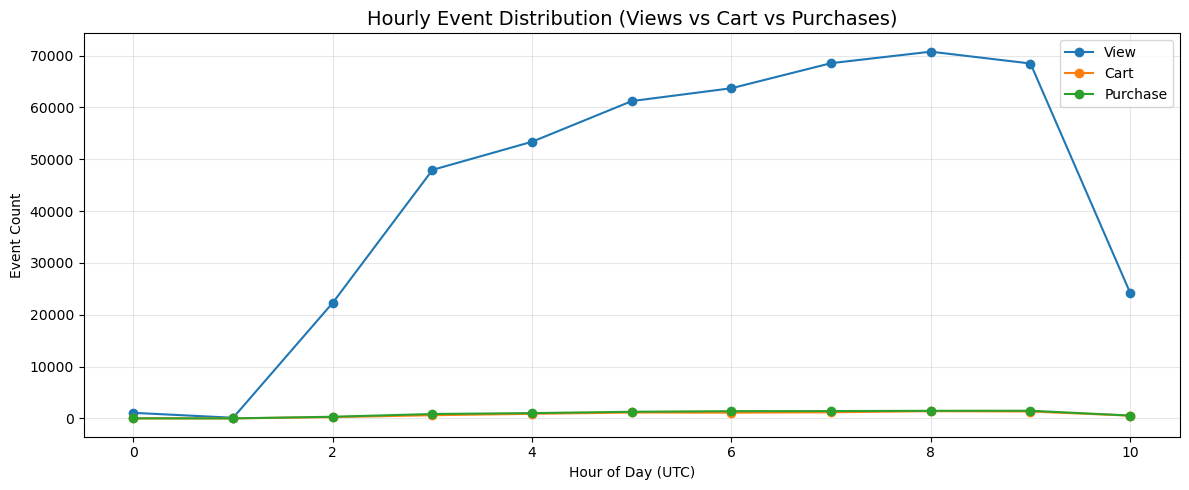

In [14]:
hourly = df.groupby(['hour','event_type']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 5))
for col, color in zip(['view','cart','purchase'], ['#1f77b4','#ff7f0e','#2ca02c']):
    if col in hourly.columns:
        plt.plot(hourly.index, hourly[col], marker='o', 
                 label=col.capitalize(), color=color)
plt.title('Hourly Event Distribution (Views vs Cart vs Purchases)', fontsize=14)
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Event Count')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('hourly_pattern.png', dpi=150)
plt.show()

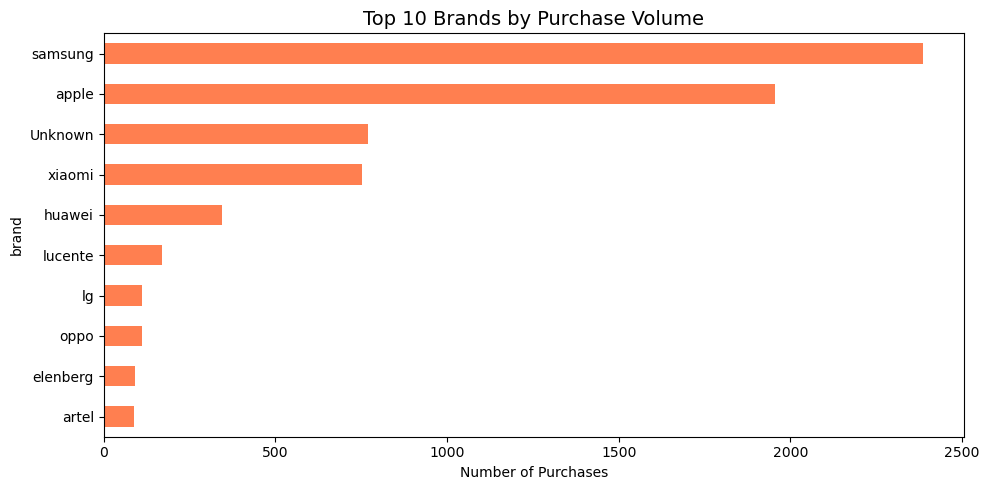

        REVENUE SUMMARY
Total Revenue:    $3,115,564.35
Avg Order Value:  $319.28
Median Order:     $181.53
Total Purchases:  9,758


In [15]:
top_brands = df[df['event_type']=='purchase']['brand'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_brands.sort_values().plot(kind='barh', color='coral')
plt.title('Top 10 Brands by Purchase Volume', fontsize=14)
plt.xlabel('Number of Purchases')
plt.tight_layout()
plt.savefig('top_brands.png', dpi=150)
plt.show()

revenue = df[df['event_type']=='purchase']['price']
print("=" * 35)
print("        REVENUE SUMMARY")
print("=" * 35)
print(f"Total Revenue:    ${revenue.sum():,.2f}")
print(f"Avg Order Value:  ${revenue.mean():.2f}")
print(f"Median Order:     ${revenue.median():.2f}")
print(f"Total Purchases:  {len(revenue):,}")

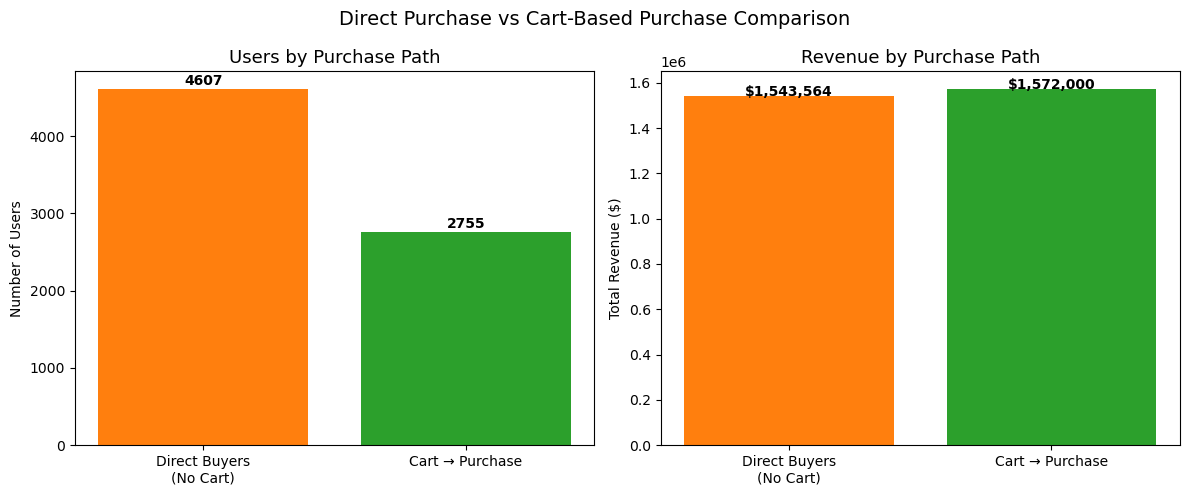

Direct buyer revenue:  $1,543,564.47
Cart buyer revenue:    $1,571,999.88


In [16]:
cart_users = set(df[df['event_type']=='cart']['user_id'])
purchase_users = set(df[df['event_type']=='purchase']['user_id'])
direct_buyers = purchase_users - cart_users
cart_then_buy = purchase_users & cart_users

direct_revenue = df[
    (df['event_type']=='purchase') & 
    (df['user_id'].isin(direct_buyers))
]['price'].sum()

cart_revenue = df[
    (df['event_type']=='purchase') & 
    (df['user_id'].isin(cart_then_buy))
]['price'].sum()

labels = ['Direct Buyers\n(No Cart)', 'Cart → Purchase']
values = [len(direct_buyers), len(cart_then_buy)]
revenues = [direct_revenue, cart_revenue]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(labels, values, color=['#ff7f0e', '#2ca02c'])
ax1.set_title('Users by Purchase Path', fontsize=13)
ax1.set_ylabel('Number of Users')
for i, v in enumerate(values):
    ax1.text(i, v + 50, str(v), ha='center', fontweight='bold')

ax2.bar(labels, revenues, color=['#ff7f0e', '#2ca02c'])
ax2.set_title('Revenue by Purchase Path', fontsize=13)
ax2.set_ylabel('Total Revenue ($)')
for i, v in enumerate(revenues):
    ax2.text(i, v + 100, f'${v:,.0f}', ha='center', fontweight='bold')

plt.suptitle('Direct Purchase vs Cart-Based Purchase Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('purchase_path_comparison.png', dpi=150)
plt.show()

print(f"Direct buyer revenue:  ${direct_revenue:,.2f}")
print(f"Cart buyer revenue:    ${cart_revenue:,.2f}")

##### Summary stats dictionary for reference
summary = {
    'total_users': total_users,
    'users_viewed': users_viewed,
    'users_carted': users_carted,
    'users_purchased': users_purchased,
    'overall_conversion': round(view_to_purchase, 2),
    'total_revenue': round(revenue.sum(), 2),
    'avg_order_value': round(revenue.mean(), 2),
    'direct_buyers': len(direct_buyers),
    'cart_buyers': len(cart_then_buy),
    'direct_revenue': round(direct_revenue, 2),
    'cart_revenue': round(cart_revenue, 2),
}

print("Summary for Report:")
for k, v in summary.items():
    print(f"  {k}: {v}")

# Save notebook
print("\nAll charts saved:")
print("  funnel_chart.png")
print("  category_conversion.png")
print("  hourly_pattern.png")
print("  top_brands.png")
print("  purchase_path_comparison.png")